In [2]:
import pandas as pd

# Only load the columns you care about, skip parsing the heavy nested 'probs' list for now
frames_df = pd.read_json(
    "all_facial_metrics.jsonl", 
    lines=True,
    dtype={'label': str, 'dj': str, 'img_path': str}  # avoids type inference overhead
)
print(frames_df.shape)


(196870, 5)


In [4]:
frames_df

,probs,label,bbox,img_path,dj
0,"[0.592173755168914, 0.08005364984273901, 0.075...",Angry,"[709, 214, 45, 57]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...
1,"[0.012304243631660002, 0.022114830091595, 0.01...",Happy,"[330, 156, 63, 84]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...
2,"[0.008428478613495001, 0.011886417865753, 0.01...",Happy,"[758, 208, 68, 93]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...
3,"[0.06961752474308, 0.10618400573730401, 0.0523...",Sad,"[136, 208, 61, 79]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...
4,"[0.13696236908435802, 0.273777514696121, 0.064...",Disgust,"[1117, 151, 81, 88]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...
...,...,...,...,...,...
196865,"[0.055132292211055006, 0.13600105047225902, 0....",Happy,"[884, 271, 61, 77]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
196866,"[0.15420262515544803, 0.34173929691314703, 0.0...",Disgust,"[782, 298, 42, 51]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
196867,"[0.12132312357425601, 0.49683877825737, 0.1682...",Disgust,"[891, 238, 35, 37]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
196868,"[0.041660126298666, 0.07227469980716701, 0.045...",Sad,"[177, 245, 38, 48]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...


In [5]:
#extract the timestamp using regex 
import re 
frames_df['timestamp'] = frames_df['img_path'].apply(lambda x: int(re.search(r'frame_(\d+)', str(x)).group(1)))
# since our fps was 1/s , leave it so it is
import pandas as pd 
audio_df = pd.read_csv("audio_features_df.csv")

In [6]:
frames_df.rename(columns={'dj': 'video_name'}, inplace=True)


In [7]:
frames_df['video_name'].value_counts()

video_name
Marlon Hoffstadt  Boiler Room Melbourne - Boiler Room (720p, h264)                                    58543
Fred again.. ｜ Boiler Room： London                                                                    45531
Chase & Status  Boiler Room London - Boiler Room (720p, h264)                                         35890
Estella Boersma  Boiler Room Festival Berlin - Boiler Room (720p, h264, youtube)                      24099
Minna-no-kimochi (みんなのきもち)  Boiler Room Tokyo Tohji Presents u-ha - Boiler Room (720p, h264)           9967
¥ØUUK€ ¥UK1MATU  Boiler Room Tokyo - Boiler Room (720p, h264)                                          4939
Yaeji  Boiler Room New York - Boiler Room (720p, h264)                                                 4292
Peggy Gou  Boiler Room x Dekmantel Festival Amsterdam - Boiler Room (720p, h264, youtube)              3720
ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)                     3605
Funky Disco & Hou

In [9]:
audio_df.rename(columns={'timestamp_start': 'timestamp'}, inplace=True)


In [10]:
audio_df['video_name'].unique()

array(['AZYR  Boiler Room x Teletech Festival 2023 - Boiler Room (720p, h264)',
       'Chase & Status  Boiler Room London - Boiler Room (720p, h264)',
       'Estella Boersma  Boiler Room Festival Berlin - Boiler Room (720p, h264, youtube)',
       'Fred again.. ｜ Boiler Room： London',
       'Funky Disco & House Mix Inside a Circus  Felix da Housecat - Book Club Radio (720p, h264, youtube)',
       'KETTAMA  Boiler Room London - Boiler Room (720p, h264)',
       'Marlon Hoffstadt  Boiler Room Melbourne - Boiler Room (720p, h264)',
       'Minna-no-kimochi (みんなのきもち)  Boiler Room Tokyo Tohji Presents u-ha - Boiler Room (720p, h264)',
       'Peggy Gou  Boiler Room x Dekmantel Festival Amsterdam - Boiler Room (720p, h264, youtube)',
       'Yaeji  Boiler Room New York - Boiler Room (720p, h264)',
       'Yung Singh  Boiler Room Melbourne - Boiler Room (720p, h264, youtube)',
       '¥ØUUK€ ¥UK1MATU  Boiler Room Tokyo - Boiler Room (720p, h264)'],
      dtype=object)

In [17]:
frames_df

,probs,label,bbox,img_path,video_name,timestamp
0,"[0.592173755168914, 0.08005364984273901, 0.075...",Angry,"[709, 214, 45, 57]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...,0
1,"[0.012304243631660002, 0.022114830091595, 0.01...",Happy,"[330, 156, 63, 84]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...,0
2,"[0.008428478613495001, 0.011886417865753, 0.01...",Happy,"[758, 208, 68, 93]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...,0
3,"[0.06961752474308, 0.10618400573730401, 0.0523...",Sad,"[136, 208, 61, 79]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...,0
4,"[0.13696236908435802, 0.273777514696121, 0.064...",Disgust,"[1117, 151, 81, 88]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,ALISHA Groovy Tech-House DJ Set Live From DJ M...,0
...,...,...,...,...,...,...
172401,"[0.19916492700576702, 0.15442527830600702, 0.1...",Sad,"[8, 283, 53, 61]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,Marlon Hoffstadt Boiler Room Melbourne - Boil...,130632
172405,"[0.07353818416595401, 0.408854573965072, 0.078...",Disgust,"[1040, 272, 37, 45]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,Marlon Hoffstadt Boiler Room Melbourne - Boil...,130632
172409,"[0.322220921516418, 0.37972229719161904, 0.070...",Disgust,"[116, 284, 46, 54]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,Marlon Hoffstadt Boiler Room Melbourne - Boil...,130644
172408,"[0.12353983521461401, 0.346417039632797, 0.070...",Disgust,"[1034, 272, 40, 51]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,Marlon Hoffstadt Boiler Room Melbourne - Boil...,130644


In [18]:
# now the interesting part regarding RL: our agent will learn based on those combined metrics
# for this exercise we can simply check for each timelapse of a song what was the percentage of happy sad neutral and normalise it, thats our reward 
# merge, cut based on track timestamp, get the metrics 

audio_df = audio_df.sort_values('timestamp')
frames_df = frames_df.sort_values('timestamp')
# double join on the dj 
frames_df_reward = pd.merge(
    audio_df,
    frames_df,
    left_on='video_name',   # column name in audio_df
    right_on='video_name',          # column name in frames_df
    how='inner'             # only keep rows that match in both
)
             # exac


In [19]:
frames_df_reward

,Unnamed: 0,dj,location,timestamp_x,song,timestamp_end,video_name,audio_path,bpm,energy,danceability,key,scale,loudness,probs,label,bbox,img_path,timestamp_y
0,127,Marlon Hoffstadt,Melbourne,0,Klubbheads - Kickin' Hard (DJ Daddy Trance Ext...,288.0,Marlon Hoffstadt Boiler Room Melbourne - Boil...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,148.950638,364964.531250,1.142021,G,minor,5329.764648,"[0.36476001143455505, 0.22837848961353302, 0.0...",Angry,"[781, 202, 60, 84]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,10
1,127,Marlon Hoffstadt,Melbourne,0,Klubbheads - Kickin' Hard (DJ Daddy Trance Ext...,288.0,Marlon Hoffstadt Boiler Room Melbourne - Boil...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,148.950638,364964.531250,1.142021,G,minor,5329.764648,"[0.04419581964612, 0.49614104628562905, 0.1948...",Disgust,"[363, 226, 56, 84]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,10
2,127,Marlon Hoffstadt,Melbourne,0,Klubbheads - Kickin' Hard (DJ Daddy Trance Ext...,288.0,Marlon Hoffstadt Boiler Room Melbourne - Boil...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,148.950638,364964.531250,1.142021,G,minor,5329.764648,"[0.019811524078249, 0.043404098600149, 0.01571...",Happy,"[898, 300, 36, 46]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,10
3,127,Marlon Hoffstadt,Melbourne,0,Klubbheads - Kickin' Hard (DJ Daddy Trance Ext...,288.0,Marlon Hoffstadt Boiler Room Melbourne - Boil...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,148.950638,364964.531250,1.142021,G,minor,5329.764648,"[0.066447779536247, 0.15958225727081302, 0.099...",Happy,"[1027, 272, 43, 57]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,10
4,127,Marlon Hoffstadt,Melbourne,0,Klubbheads - Kickin' Hard (DJ Daddy Trance Ext...,288.0,Marlon Hoffstadt Boiler Room Melbourne - Boil...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,148.950638,364964.531250,1.142021,G,minor,5329.764648,"[0.32975000143051103, 0.35178324580192505, 0.1...",Disgust,"[286, 277, 48, 55]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3567404,111,Felix Da Housecat,Circus,6750,3 Winans Brothers - Dance (Louie Vega Dance Ri...,inf,Funky Disco & House Mix Inside a Circus Felix...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,123.953995,121614.007812,1.115142,G,major,2552.343262,"[0.26947367191314703, 0.131706967949867, 0.036...",Happy,"[0, 315, 45, 67]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,6430
3567405,111,Felix Da Housecat,Circus,6750,3 Winans Brothers - Dance (Louie Vega Dance Ri...,inf,Funky Disco & House Mix Inside a Circus Felix...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,123.953995,121614.007812,1.115142,G,major,2552.343262,"[0.17459414899349202, 0.319065123796463, 0.140...",Disgust,"[225, 261, 22, 29]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,6430
3567406,111,Felix Da Housecat,Circus,6750,3 Winans Brothers - Dance (Louie Vega Dance Ri...,inf,Funky Disco & House Mix Inside a Circus Felix...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,123.953995,121614.007812,1.115142,G,major,2552.343262,"[0.200491860508918, 0.325450241565704, 0.17877...",Disgust,"[809, 240, 35, 45]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,6430
3567407,111,Felix Da Housecat,Circus,6750,3 Winans Brothers - Dance (Louie Vega Dance Ri...,inf,Funky Disco & House Mix Inside a Circus Felix...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,123.953995,121614.007812,1.115142,G,major,2552.343262,"[0.196483045816421, 0.595456361770629, 0.10838...",Disgust,"[234, 233, 27, 35]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,6430


In [45]:
frames_df_reward.loc[frames_df_reward['dj'] == 'AZYR']

,Unnamed: 0,dj,location,timestamp_x,song,timestamp_end,video_name,audio_path,bpm,energy,danceability,key,scale,loudness,probs,label,bbox,img_path,timestamp_y
97943,0,AZYR,Teletech,7,Smac U - The intro,102.0,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,155.181442,64804.484375,1.079845,C,minor,1674.077148,"[0.18292938172817202, 0.167305573821067, 0.168...",Sad,"[792, 168, 59, 84]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,6
97944,0,AZYR,Teletech,7,Smac U - The intro,102.0,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,155.181442,64804.484375,1.079845,C,minor,1674.077148,"[0.161277070641517, 0.312230765819549, 0.18166...",Disgust,"[1014, 125, 106, 127]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,6
97945,0,AZYR,Teletech,7,Smac U - The intro,102.0,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,155.181442,64804.484375,1.079845,C,minor,1674.077148,"[0.057910706847906, 0.43730598688125605, 0.105...",Disgust,"[247, 256, 47, 54]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,6
97946,0,AZYR,Teletech,7,Smac U - The intro,102.0,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,155.181442,64804.484375,1.079845,C,minor,1674.077148,"[0.208167254924774, 0.42148447036743103, 0.175...",Disgust,"[30, 282, 49, 59]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,7
97947,0,AZYR,Teletech,7,Smac U - The intro,102.0,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,155.181442,64804.484375,1.079845,C,minor,1674.077148,"[0.09071435034275001, 0.44317340850830006, 0.1...",Disgust,"[333, 179, 66, 77]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915342,21,AZYR,Teletech,3290,- Infectious - I need your lovin (95 happy har...,inf,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,172.265274,223786.765625,1.089670,Eb,minor,3840.512207,"[0.01956757158041, 0.026358047500252002, 0.028...",Happy,"[869, 184, 19, 23]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,3582
2915343,21,AZYR,Teletech,3290,- Infectious - I need your lovin (95 happy har...,inf,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,172.265274,223786.765625,1.089670,Eb,minor,3840.512207,"[0.09818841516971501, 0.13994075357913902, 0.1...",Sad,"[766, 588, 18, 22]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,3583
2915344,21,AZYR,Teletech,3290,- Infectious - I need your lovin (95 happy har...,inf,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,172.265274,223786.765625,1.089670,Eb,minor,3840.512207,"[0.22637724876403803, 0.19546738266944802, 0.1...",Angry,"[19, 576, 17, 23]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,3583
2915345,21,AZYR,Teletech,3290,- Infectious - I need your lovin (95 happy har...,inf,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,172.265274,223786.765625,1.089670,Eb,minor,3840.512207,"[0.139452710747718, 0.27254596352577204, 0.170...",Disgust,"[28, 550, 21, 26]",/Users/fokia/CentraleSupelec-CV-and-RL-project...,3584


audio_df video_name sample: ['Marlon Hoffstadt  Boiler Room Melbourne - Boiler Room (720p, h264)', 'KETTAMA  Boiler Room London - Boiler Room (720p, h264)', 'Funky Disco & House Mix Inside a Circus  Felix da Housecat - Book Club Radio (720p, h264, youtube)']
frames_df dj sample: ['ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)', 'ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)', 'ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)']


In [48]:
from tqdm import tqdm
from collections import Counter
import pandas as pd

tqdm.pandas()

emotion_mapper = {
    'Angry':    'Positive',  # locked in!
    'Disgust':  'Neutral',
    'Fear':     'Negative',
    'Sad':      'Negative',
    'Happy':    'Positive',
    'Surprise': 'Positive',
    'Neutral':  'Neutral'
}

def aggregate_per_song(audio_row):
    mask = (
        (frames_df['video_name'] == audio_row['video_name']) &  
        (frames_df['timestamp'] >= audio_row['timestamp']) &
        (frames_df['timestamp'] <= audio_row['timestamp_end'])
    )
    labels = frames_df.loc[mask, 'label'].dropna()
    labels = labels[labels != 'None']  # exclude no-detection rows
    total = len(labels)
    
    if total == 0:
        return pd.Series({'pct_Positive': 0, 'pct_Neutral': 0, 'pct_Negative': 0, 'face_count': 0})
    
    # Map each raw label -> Positive / Neutral / Negative
    sentiment_labels = labels.map(emotion_mapper)
    counts = Counter(sentiment_labels)
    
    return pd.Series({
        'pct_Positive': counts.get('Positive', 0) / total,
        'pct_Neutral':  counts.get('Neutral',  0) / total,
        'pct_Negative': counts.get('Negative', 0) / total,
        'face_count':   total
    })

emotion_cols = audio_df.progress_apply(aggregate_per_song, axis=1)
result_df = pd.concat([audio_df.reset_index(drop=True), emotion_cols], axis=1)
print(result_df.shape)
result_df.head()


100%|██████████| 207/207 [00:01<00:00, 144.31it/s]

(207, 18)


,Unnamed: 0,dj,location,timestamp,song,timestamp_end,video_name,audio_path,bpm,energy,danceability,key,scale,loudness,pct_Positive,pct_Neutral,pct_Negative,face_count
0,127,Marlon Hoffstadt,Melbourne,0,Klubbheads - Kickin' Hard (DJ Daddy Trance Ext...,288.0,Marlon Hoffstadt Boiler Room Melbourne - Boil...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,148.950638,3.649645e+05,1.142021,G,minor,5329.764648,0.384615,0.461538,0.153846,13.0
1,112,KETTAMA,London,0,Jump (Rushing mix)- Soul Mass Transit System,320.0,KETTAMA Boiler Room London - Boiler Room (720...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,140.496231,4.620757e+05,1.066279,F#,minor,6242.490234,0.313433,0.567164,0.119403,67.0
2,79,Felix Da Housecat,Circus,0,Gino Soccio - Dancer ( ??? Remix),350.0,Funky Disco & House Mix Inside a Circus Felix...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,124.961143,2.614855e+05,1.628826,F,minor,4262.751465,0.370370,0.333333,0.296296,27.0
3,22,Chase & Status,London,0,Chase & Status & Mozey ft. Sav'o & Horrid1 - O...,381.0,Chase & Status Boiler Room London - Boiler Ro...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,172.265518,1.851701e+06,1.160073,G,minor,15822.408203,0.166667,0.416667,0.416667,12.0
4,0,AZYR,Teletech,7,Smac U - The intro,102.0,AZYR Boiler Room x Teletech Festival 2023 - B...,/Users/fokia/CentraleSupelec-CV-and-RL-project...,155.181442,6.480448e+04,1.079845,C,minor,1674.077148,0.280000,0.440000,0.280000,25.0


In [ ]:
def compute_reward(row):
    return (
        row['pct_Positive'] * 1.0 # reward positive crowd energy fully
      + row['pct_Neutral']  * 0.0    # neutral = no reward, no penalty
      + row['pct_Negative'] * -1.0  # penalize sad/fearful crowd reactions
    )

result_df['reward'] = result_df.apply(compute_reward, axis=1)


<Axes: >

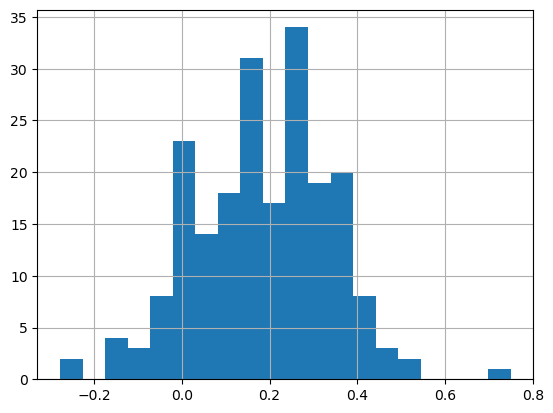

In [51]:
result_df['reward'].describe()
result_df['reward'].hist(bins=20)


In [53]:
reward_csv = result_df.to_csv("rewards.csv")

In [21]:
result_df

NameError: name 'result_df' is not defined